In [ ]:
import numpy as np

In [6]:
def ou_2d(T,dt, theta, sigma):
    # T = length of sequence
    # dt = time step size
    # sigma = how noisy it is
    # theta = how strongly it pulls towards center 

    x=np.zeros((T,2))
    x[0] = np.random.randn(2) #random initial condition

    for t in range (1,T):
        dW = np.sqrt(dt) * np.random.randn(2)
        x[t] = x[t-1] - theta*x[t-1]*dt+ sigma*dW #OU SDE
    
    return x

In [ ]:
def generate_dataset(num_sequences):
    return[ou_2d() for _ in range(num_sequences)]

In [4]:
def make_training_pairs(sequence, k=10):
    #k = context length

    inputs = [] #last k points
    targets = [] # next point

    for t in range(k, len(sequence)):
        inputs.append(sequence[t-k:t])
        targets.append(sequence[t])

    return np.array(inputs), np.array(targets)

In [36]:
seq = ou_2d(1000,0.01,0.5,0.3)
print(seq.shape)

(1000, 2)


In [9]:
import matplotlib.pyplot as plt

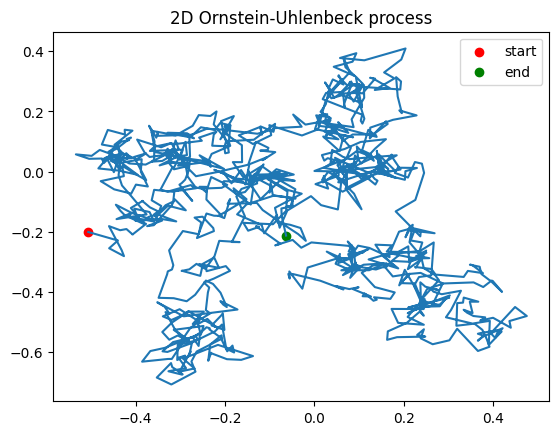

In [37]:
plt.plot(seq[:,0], seq[:,1]) #seq[:,0] = x-coord, seq[:,1] = y-coord
plt.scatter(seq[0,0], seq[0,1], color='red', label='start')
plt.scatter(seq[-1,0], seq[-1,1], color='green', label='end')  # end
plt.legend()
plt.title("2D Ornstein-Uhlenbeck process")
plt.show()